<a href="https://colab.research.google.com/github/tassegaetan1/colab-git-assignment2-UT/blob/main/Project3_Trading_Signals_ML_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 3: Predicting Buy, Sell, and Hold Stock Trading Signals

## Supervised Machine Learning with Manually Computed Technical Indicators

This notebook develops supervised machine learning models to predict **Buy**, **Sell**, and **Hold** trading signals using historical stock price data.

### Indicators
- MACD
- RSI
- Bollinger Bands

### Models
- Logistic Regression
- Random Forest
- Support Vector Machine (SVM)

### Evaluation
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Cross-validation


In [6]:
# =========================
# 1. Import Libraries
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings("ignore")


## 2. Mount Google Drive and Load Dataset

This notebook uses the extracted CSV file in Google Drive.

Expected path:

`/content/drive/MyDrive/Willis doc/historical_stock_prices.csv`

If your folder name is different, update `prices_path`.


In [7]:
# =========================
# 2. Mount Google Drive
# =========================

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# =========================
# 3. Load Data
# =========================

prices_path = "/content/drive/MyDrive/Willis_doc/historical_stock_prices.csv"

# For fast execution, use nrows first. Increase or remove nrows for the final run.
df = pd.read_csv(prices_path, nrows=300000)

df.columns = df.columns.str.lower().str.strip()
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

print("Dataset shape:", df.shape)
display(df.head())
display(df.dtypes)


Dataset shape: (300000, 8)


,ticker,open,close,adj_close,low,high,volume,date
0,AAPL,0.513393,0.513393,0.023186,0.513393,0.515625,117258400,1980-12-12
1,AAPL,0.488839,0.486607,0.021977,0.486607,0.488839,43971200,1980-12-15
2,AAPL,0.453125,0.450893,0.020364,0.450893,0.453125,26432000,1980-12-16
3,AAPL,0.462054,0.462054,0.020868,0.462054,0.464286,21610400,1980-12-17
4,AAPL,0.475446,0.475446,0.021473,0.475446,0.477679,18362400,1980-12-18


,0
ticker,object
open,float64
close,float64
adj_close,float64
low,float64
high,float64
volume,int64
date,datetime64[ns]


## 3. Data Cleaning

Cleaning steps:
- Remove duplicate rows.
- Drop rows missing ticker, date, or close price.
- Remove impossible negative values.
- Sort data chronologically by ticker.


In [9]:
# =========================
# 4. Data Cleaning
# =========================

print("Missing values before cleaning:")
display(df.isnull().sum())

df = df.drop_duplicates()
df = df.dropna(subset=["ticker", "date", "close"])

for col in ["open", "high", "low", "close", "adj_close", "volume"]:
    if col in df.columns:
        df = df[df[col] >= 0]

df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

print("Dataset shape after cleaning:", df.shape)
display(df.head())


Missing values before cleaning:


,0
ticker,0
open,0
close,0
adj_close,0
low,0
high,0
volume,0
date,0


Dataset shape after cleaning: (300000, 8)


,ticker,open,close,adj_close,low,high,volume,date
0,AAPL,0.513393,0.513393,0.023186,0.513393,0.515625,117258400,1980-12-12
1,AAPL,0.488839,0.486607,0.021977,0.486607,0.488839,43971200,1980-12-15
2,AAPL,0.453125,0.450893,0.020364,0.450893,0.453125,26432000,1980-12-16
3,AAPL,0.462054,0.462054,0.020868,0.462054,0.464286,21610400,1980-12-17
4,AAPL,0.475446,0.475446,0.021473,0.475446,0.477679,18362400,1980-12-18


## 4. Manual MACD Calculation

MACD is calculated manually as:

`MACD = EMA12(close) - EMA26(close)`

Signal line:

`Signal Line = EMA9(MACD)`


In [10]:
# =========================
# 5. Manual MACD
# =========================

df["ema12"] = df.groupby("ticker")["close"].transform(
    lambda x: x.ewm(span=12, adjust=False).mean()
)

df["ema26"] = df.groupby("ticker")["close"].transform(
    lambda x: x.ewm(span=26, adjust=False).mean()
)

df["macd"] = df["ema12"] - df["ema26"]

df["macd_signal_line"] = df.groupby("ticker")["macd"].transform(
    lambda x: x.ewm(span=9, adjust=False).mean()
)

df["macd_histogram"] = df["macd"] - df["macd_signal_line"]

display(df[["ticker", "date", "close", "macd", "macd_signal_line", "macd_histogram"]].head(20))


,ticker,date,close,macd,macd_signal_line,macd_histogram
0,AAPL,1980-12-12,0.513393,0.000000,0.000000,0.000000
1,AAPL,1980-12-15,0.486607,-0.002137,-0.000427,-0.001709
2,AAPL,1980-12-16,0.450893,-0.006635,-0.001669,-0.004967
3,AAPL,1980-12-17,0.462054,-0.009194,-0.003174,-0.006020
4,AAPL,1980-12-18,0.475446,-0.010026,-0.004544,-0.005481
5,AAPL,1980-12-19,0.504464,-0.008248,-0.005285,-0.002963
6,AAPL,1980-12-22,0.529018,-0.004803,-0.005189,0.000386
7,AAPL,1980-12-23,0.551339,-0.000268,-0.004205,0.003936
8,AAPL,1980-12-24,0.580357,0.005603,-0.002243,0.007846
9,AAPL,1980-12-26,0.633929,0.014412,0.001088,0.013324


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Run

## 5. Manual RSI Calculation

RSI is calculated manually as:

`RSI = 100 - (100 / (1 + RS))`

where:

`RS = EMA(Gain) / EMA(Loss)`


In [11]:
# =========================
# 6. Manual RSI
# =========================

delta = df.groupby("ticker")["close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.groupby(df["ticker"]).transform(
    lambda x: x.ewm(span=14, adjust=False).mean()
)

avg_loss = loss.groupby(df["ticker"]).transform(
    lambda x: x.ewm(span=14, adjust=False).mean()
)

rs = avg_gain / avg_loss.replace(0, np.nan)

df["rsi"] = 100 - (100 / (1 + rs))

display(df[["ticker", "date", "close", "rsi"]].head(20))


,ticker,date,close,rsi
0,AAPL,1980-12-12,0.513393,NaN
1,AAPL,1980-12-15,0.486607,0.000000
2,AAPL,1980-12-16,0.450893,0.000000
3,AAPL,1980-12-17,0.462054,5.782567
4,AAPL,1980-12-18,0.475446,12.767003
5,AAPL,1980-12-19,0.504464,26.405986
6,AAPL,1980-12-22,0.529018,36.152379
7,AAPL,1980-12-23,0.551339,43.940063
8,AAPL,1980-12-24,0.580357,52.610443
9,AAPL,1980-12-26,0.633929,64.354256


## 6. Manual Bollinger Bands Calculation

Bollinger Bands:
- Middle Band = 20-day rolling mean
- Upper Band = Middle Band + 2 × rolling standard deviation
- Lower Band = Middle Band - 2 × rolling standard deviation


In [12]:
# =========================
# 7. Manual Bollinger Bands
# =========================

df["bb_middle"] = df.groupby("ticker")["close"].transform(
    lambda x: x.rolling(window=20).mean()
)

df["bb_std"] = df.groupby("ticker")["close"].transform(
    lambda x: x.rolling(window=20).std()
)

df["bb_upper"] = df["bb_middle"] + (2 * df["bb_std"])
df["bb_lower"] = df["bb_middle"] - (2 * df["bb_std"])
df["bb_width"] = (df["bb_upper"] - df["bb_lower"]) / df["bb_middle"]

display(df[["ticker", "date", "close", "bb_lower", "bb_middle", "bb_upper", "bb_width"]].head(25))


,ticker,date,close,bb_lower,bb_middle,bb_upper,bb_width
0,AAPL,1980-12-12,0.513393,NaN,NaN,NaN,NaN
1,AAPL,1980-12-15,0.486607,NaN,NaN,NaN,NaN
2,AAPL,1980-12-16,0.450893,NaN,NaN,NaN,NaN
3,AAPL,1980-12-17,0.462054,NaN,NaN,NaN,NaN
4,AAPL,1980-12-18,0.475446,NaN,NaN,NaN,NaN
5,AAPL,1980-12-19,0.504464,NaN,NaN,NaN,NaN
6,AAPL,1980-12-22,0.529018,NaN,NaN,NaN,NaN
7,AAPL,1980-12-23,0.551339,NaN,NaN,NaN,NaN
8,AAPL,1980-12-24,0.580357,NaN,NaN,NaN,NaN
9,AAPL,1980-12-26,0.633929,NaN,NaN,NaN,NaN


## 7. Generate Buy, Sell, and Hold Signals

Rules:
- MACD Buy: MACD crosses above signal line.
- MACD Sell: MACD crosses below signal line.
- RSI Buy: RSI < 30.
- RSI Sell: RSI > 70.

Final signal:
- Buy if both MACD and RSI indicate Buy.
- Sell if both MACD and RSI indicate Sell.
- Hold otherwise.


In [13]:
# =========================
# 8. Create Trading Signals
# =========================

df["macd_prev"] = df.groupby("ticker")["macd"].shift(1)
df["macd_signal_prev"] = df.groupby("ticker")["macd_signal_line"].shift(1)

df["macd_buy"] = (df["macd_prev"] <= df["macd_signal_prev"]) & (df["macd"] > df["macd_signal_line"])
df["macd_sell"] = (df["macd_prev"] >= df["macd_signal_prev"]) & (df["macd"] < df["macd_signal_line"])

df["rsi_buy"] = df["rsi"] < 30
df["rsi_sell"] = df["rsi"] > 70

df["final_signal"] = "Hold"
df.loc[df["macd_buy"] & df["rsi_buy"], "final_signal"] = "Buy"
df.loc[df["macd_sell"] & df["rsi_sell"], "final_signal"] = "Sell"

print("Signal distribution:")
display(df["final_signal"].value_counts())


Signal distribution:


,count
final_signal,
Hold,299769
Buy,119
Sell,112


## 8. Visualize Technical Indicators

Sample ticker: AAPL


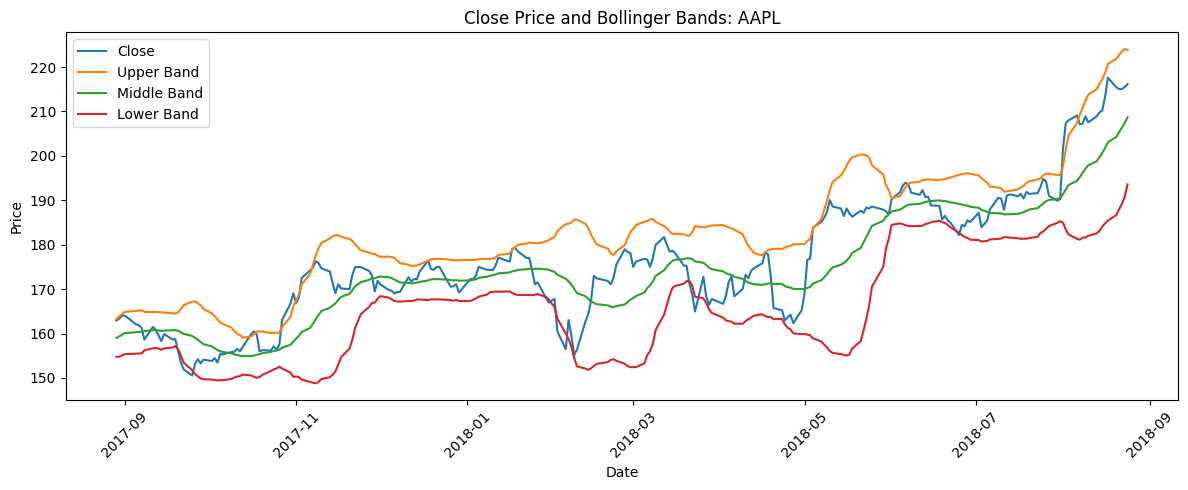

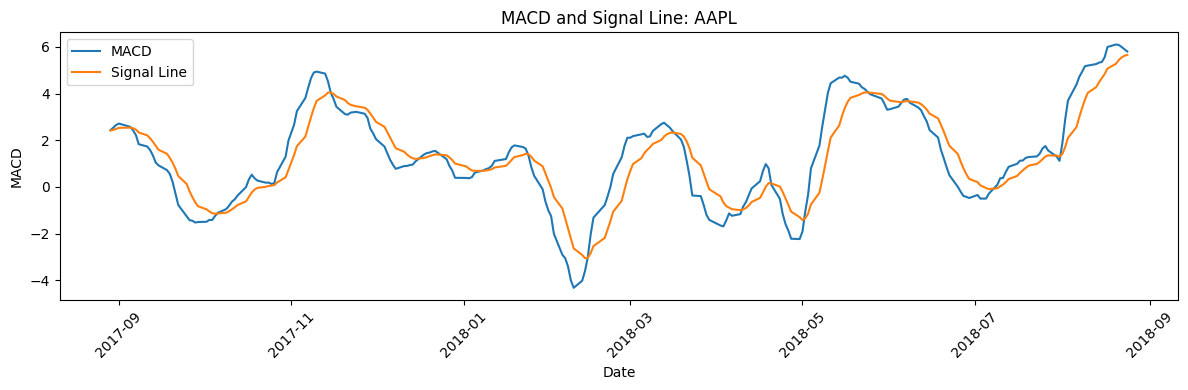

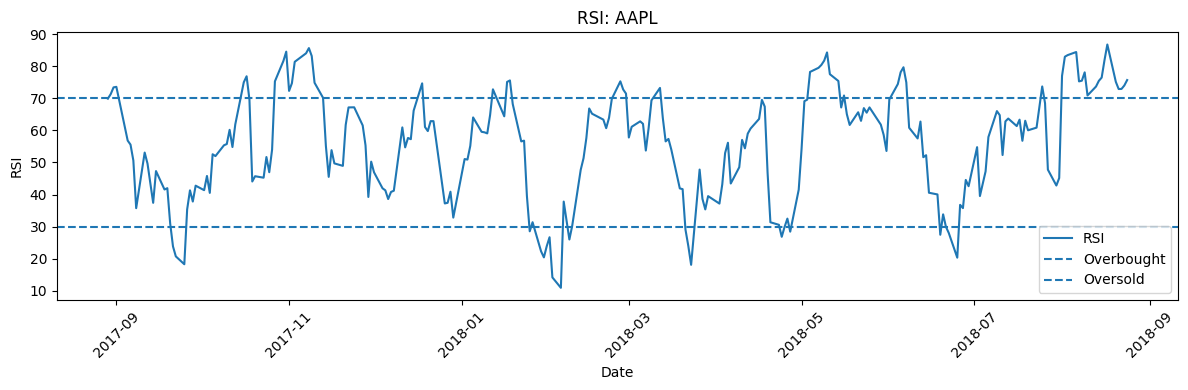

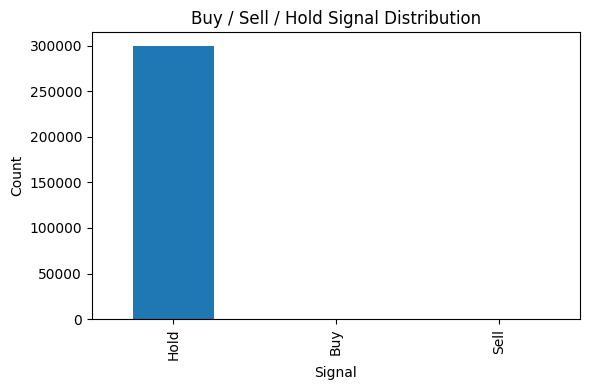

In [14]:
# =========================
# 9. Visualizations
# =========================

sample_ticker = df["ticker"].dropna().unique()[0]
sample = df[df["ticker"] == sample_ticker].dropna().tail(250)

print("Sample ticker:", sample_ticker)

plt.figure(figsize=(12, 5))
plt.plot(sample["date"], sample["close"], label="Close")
plt.plot(sample["date"], sample["bb_upper"], label="Upper Band")
plt.plot(sample["date"], sample["bb_middle"], label="Middle Band")
plt.plot(sample["date"], sample["bb_lower"], label="Lower Band")
plt.title(f"Close Price and Bollinger Bands: {sample_ticker}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(sample["date"], sample["macd"], label="MACD")
plt.plot(sample["date"], sample["macd_signal_line"], label="Signal Line")
plt.title(f"MACD and Signal Line: {sample_ticker}")
plt.xlabel("Date")
plt.ylabel("MACD")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(sample["date"], sample["rsi"], label="RSI")
plt.axhline(70, linestyle="--", label="Overbought")
plt.axhline(30, linestyle="--", label="Oversold")
plt.title(f"RSI: {sample_ticker}")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
df["final_signal"].value_counts().plot(kind="bar")
plt.title("Buy / Sell / Hold Signal Distribution")
plt.xlabel("Signal")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 9. Prepare Dataset for Machine Learning

In [15]:
# =========================
# 10. ML Dataset Preparation
# =========================

feature_cols = [
    "close",
    "volume",
    "macd",
    "macd_signal_line",
    "macd_histogram",
    "rsi",
    "bb_width"
]

ml_df = df[feature_cols + ["final_signal", "date"]].replace([np.inf, -np.inf], np.nan).dropna()

signal_map = {"Sell": -1, "Hold": 0, "Buy": 1}
ml_df["target"] = ml_df["final_signal"].map(signal_map)

ml_df = ml_df.sort_values("date").reset_index(drop=True)

X = ml_df[feature_cols]
y = ml_df["target"]

print("ML dataset shape:", ml_df.shape)
print("Target distribution:")
display(ml_df["final_signal"].value_counts())
display(ml_df.head())


ML dataset shape: (298442, 10)
Target distribution:


,count
final_signal,
Hold,298230
Buy,108
Sell,104


,close,volume,macd,macd_signal_line,macd_histogram,rsi,bb_width,final_signal,date,target
0,0.867188,1248000,0.004656,0.005494,-0.000838,34.860493,0.061442,Hold,1972-06-28,0
1,0.880208,1060800,0.004619,0.005319,-0.000700,50.053093,0.060482,Hold,1972-06-29,0
2,0.882812,2774400,0.004746,0.005204,-0.000458,52.604092,0.055461,Hold,1972-06-30,0
3,0.885417,782400,0.004999,0.005163,-0.000164,55.241775,0.047470,Hold,1972-07-03,0
4,0.901042,2755200,0.006386,0.005408,0.000979,67.690145,0.051864,Hold,1972-07-05,0


## 10. Time-Based Train/Test Split

Stock data is time-based, so the split is chronological. Older observations are used for training and newer observations are used for testing.


In [16]:
# =========================
# 11. Time-Based Split
# =========================

split_index = int(len(ml_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (238753, 7)
Testing shape: (59689, 7)


## 11. Train Logistic Regression, Random Forest, and SVM

In [17]:
# =========================
# 12. Model Training and Evaluation
# =========================

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", class_weight="balanced"))
    ])
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    print(f"\n{name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Sell", "Hold", "Buy"]))
    print("-" * 70)


Training Logistic Regression...

Logistic Regression Accuracy: 0.7930
              precision    recall  f1-score   support

        Sell       0.00      0.96      0.01        28
        Hold       1.00      0.79      0.88     59635
         Buy       0.00      0.92      0.01        26

    accuracy                           0.79     59689
   macro avg       0.34      0.89      0.30     59689
weighted avg       1.00      0.79      0.88     59689

----------------------------------------------------------------------
Training Random Forest...

Random Forest Accuracy: 0.9976
              precision    recall  f1-score   support

        Sell       0.20      0.50      0.28        28
        Hold       1.00      1.00      1.00     59635
         Buy       0.21      0.65      0.32        26

    accuracy                           1.00     59689
   macro avg       0.47      0.72      0.53     59689
weighted avg       1.00      1.00      1.00     59689

---------------------------------------

## 12. Confusion Matrices

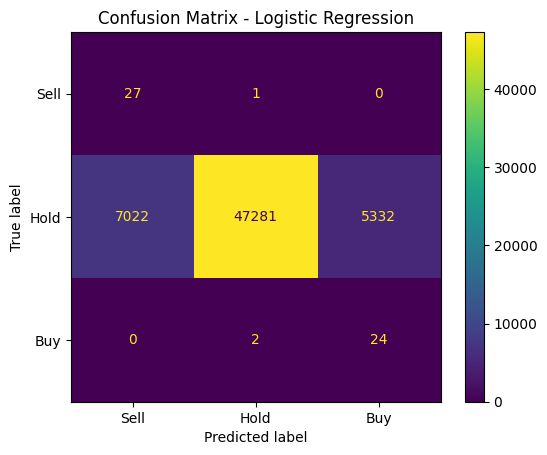

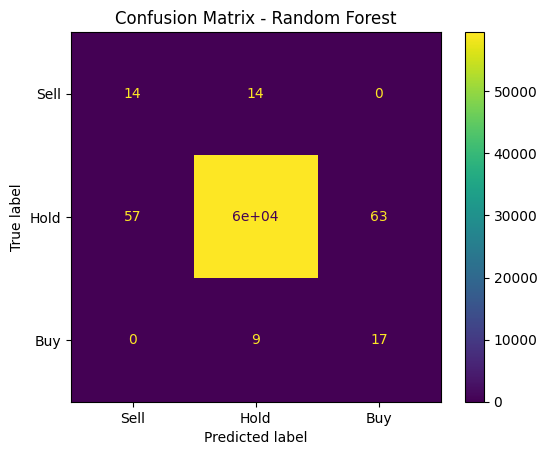

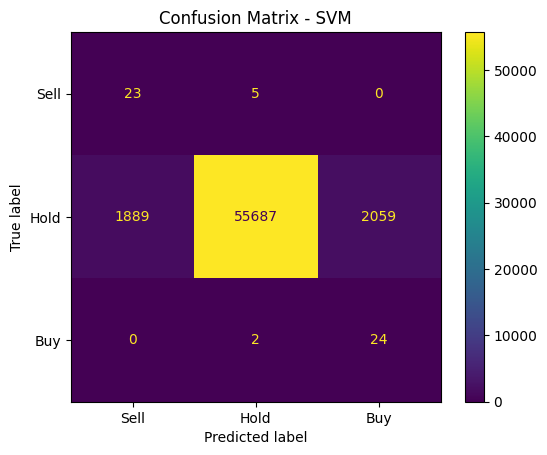

In [18]:
# =========================
# 13. Confusion Matrices
# =========================

class_labels = ["Sell", "Hold", "Buy"]

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=[-1, 0, 1])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


## 13. Model Accuracy Comparison

,Accuracy
Random Forest,0.997604
SVM,0.933740
Logistic Regression,0.792977


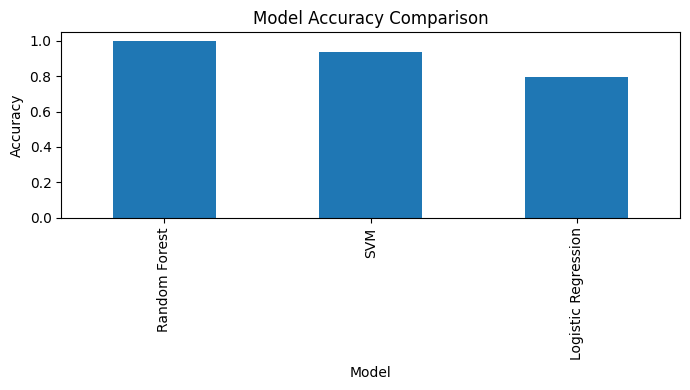

In [19]:
# =========================
# 14. Model Comparison
# =========================

results_df = pd.DataFrame.from_dict(
    results,
    orient="index",
    columns=["Accuracy"]
).sort_values("Accuracy", ascending=False)

display(results_df)

plt.figure(figsize=(7, 4))
results_df["Accuracy"].plot(kind="bar")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.tight_layout()
plt.show()


## 14. Cross-Validation

In [20]:
# =========================
# 15. Cross-Validation
# =========================

cv_results = {}

for name, model in models.items():
    print(f"Cross-validating {name}...")
    scores = cross_val_score(model, X, y, cv=3, scoring="accuracy")
    cv_results[name] = {
        "Mean CV Accuracy": scores.mean(),
        "Std CV Accuracy": scores.std()
    }

cv_df = pd.DataFrame(cv_results).T
display(cv_df)


Cross-validating Logistic Regression...
Cross-validating Random Forest...
Cross-validating SVM...


,Mean CV Accuracy,Std CV Accuracy
Logistic Regression,0.781304,0.017597
Random Forest,0.998244,0.000203
SVM,0.941667,0.013122


## 15. Predict a New Trading Signal

In [21]:
# =========================
# 16. Predict New Signal Example
# =========================

best_model_name = results_df.index[0]
best_model = models[best_model_name]

new_sample = X_test.iloc[[0]]
predicted_signal = best_model.predict(new_sample)[0]

reverse_signal_map = {-1: "Sell", 0: "Hold", 1: "Buy"}

print("Best model:", best_model_name)
print("Predicted signal:", reverse_signal_map[predicted_signal])
display(new_sample)


Best model: Random Forest
Predicted signal: Hold


,close,volume,macd,macd_signal_line,macd_histogram,rsi,bb_width
238753,14.82,663900,-0.419236,-0.166885,-0.252352,34.938842,0.250795


## 16. Conclusion

This project demonstrates how manually computed technical indicators can be used to create supervised learning labels for stock trading decisions.

### Key conclusions
- MACD captures trend and momentum changes.
- RSI captures overbought and oversold market conditions.
- Bollinger Bands add volatility information.
- Machine learning models can learn trading signal patterns from these indicators.
- Random Forest often performs well because it can capture nonlinear relationships.

### Financial interpretation
These models can support trading decision-making, but they should not replace risk management, transaction cost analysis, or expert judgment.
